# Analyse des ventes du site web de la librairie Lapage

## Etape 1 - Importation des librairies et chargement des fichiers

### 1.1 - Importation des librairies et paramétrage

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie NumPy
import numpy as np

In [3]:
#Importation de la librairie Matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

In [4]:
#Importation de la librairie Seaborn
import seaborn as sns

In [5]:
#Importation des librairies de tests statistiques
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import f_oneway

In [6]:
#Afficher toutes les colonnes d'un dataframe et monter le maximum de lignes affichées à 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### 1.2 - Chargement des fichiers

In [7]:
#Connecter au Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#Importation du fichier customers.csv
df_customers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data P9/customers.csv', sep=';')

In [9]:
#Importation du fichier products.csv
df_products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data P9/products.csv', sep=';')

In [10]:
#Importation du fichier Transactions.csv
df_transactions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data P9/Transactions.csv', sep=';', low_memory=False)

## Etape 2 - Analyse exploratoire des fichiers

### 2.1 - Analyse exploratoire du fichier customers.csv

In [11]:
#Dimension et caractéristiques du dataset customers.csv
df_customers.info()
print("\n")
df_customers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB




,client_id,sex,birth
count,8621,8621,8621.000000
unique,8621,2,NaN
top,c_84,f,NaN
freq,1,4490,NaN
mean,NaN,NaN,1978.275606
std,NaN,NaN,16.917958
min,NaN,NaN,1929.000000
25%,NaN,NaN,1966.000000
50%,NaN,NaN,1979.000000
75%,NaN,NaN,1992.000000


In [12]:
#Premières lignes du dataset customers.csv
df_customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [13]:
#Dernières lignes du dataset customers.csv
df_customers.tail()

,client_id,sex,birth
8616,c_7920,m,1956
8617,c_7403,f,1970
8618,c_5119,m,1974
8619,c_5643,f,1968
8620,c_84,f,1982


In [14]:
#Valeurs distinctes de la colonne 'sex' du dataset customers.csv
df_customers['sex'].value_counts()

,count
sex,
f,4490
m,4131


Résultat de l'analyse :
* Aucune cellule vide,
* Ensemble de données cohérent,
* Clé primaire unique : client_id.

### 2.2 - Analyse exploratoire du fichier products.csv

In [15]:
#Dimensions et caratéristiques du dataset products.csv
df_products.info()
print("\n")
df_products.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB




,id_prod,price,categ
count,3286,3286.000000,3286.000000
unique,3286,NaN,NaN
top,0_1920,NaN,NaN
freq,1,NaN,NaN
mean,NaN,21.863597,0.370359
std,NaN,29.849786,0.615446
min,NaN,0.620000,0.000000
25%,NaN,6.990000,0.000000
50%,NaN,13.075000,0.000000
75%,NaN,22.990000,1.000000


In [16]:
#Premières lignes du dataset products.csv
df_products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [17]:
#Dernières lignes du dataset products.csv
df_products.tail()

,id_prod,price,categ
3281,2_23,115.99,2
3282,0_146,17.14,0
3283,0_802,11.22,0
3284,1_140,38.56,1
3285,0_1920,25.16,0


In [18]:
#Valeurs distinctes de la colonne 'categ' du dataset products.csv
df_products['categ'].value_counts()

,count
categ,
0,2308
1,739
2,239


Résultat de l'analyse :
* Aucune cellule vide,
* Ensemble de données cohérent,
* Clé primaire unique : id_prod.

### 2.1 - Analyse exploratoire du fichier Transactions.csv

In [19]:
#Dimensions et caratéristiques du dataset Transactions.csv
df_transactions.info()
print("\n")
df_transactions.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB




,id_prod,date,session_id,client_id
count,687534,687534,687534,687534
unique,3265,687419,345505,8600
top,1_369,2021-10-03 11:54:55.781188,s_118668,c_1609
freq,2340,2,14,25586


In [20]:
#Premières lignes du dataset Transactions.csv
df_transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [21]:
#Dernières lignes du dataset Transactions.csv
df_transactions.tail()

,id_prod,date,session_id,client_id
1048570,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN
1048574,NaN,NaN,NaN,NaN


Résultat de l'analyse :
* Ensemble de données cohérent,
* Présence de lignes vides,
* Pas de clé primaire identifiée.

In [22]:
#Création d'une copie du dataframe 'df_transactions' pour mise en forme
df_transactions_analyse = df_transactions.copy()

In [23]:
#Suppression des lignes vides
df_transactions_analyse = df_transactions_analyse.dropna()

In [24]:
#création d'une clé primaire
df_transactions_analyse['transaction_id']=df_transactions_analyse['client_id']+'_'+df_transactions_analyse['id_prod']+'_'+df_transactions_analyse['date']

#Dimensions et caractéristiques du nouveau dataframe
df_transactions_analyse.info()
print("\n")
df_transactions_analyse.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_prod         687534 non-null  object
 1   date            687534 non-null  object
 2   session_id      687534 non-null  object
 3   client_id       687534 non-null  object
 4   transaction_id  687534 non-null  object
dtypes: object(5)
memory usage: 31.5+ MB




,id_prod,date,session_id,client_id,transaction_id
count,687534,687534,687534,687534,687534
unique,3265,687419,345505,8600,687534
top,1_369,2021-10-03 11:54:55.781188,s_118668,c_1609,c_3575_0_1398_2023-02-28 23:58:30.792755
freq,2340,2,14,25586,1


In [25]:
#Premières lignes du dataframe 'df_transactions_analyse'
df_transactions_analyse.head()

,id_prod,date,session_id,client_id,transaction_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,c_329_0_1259_2021-03-01 00:01:07.843138
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,c_664_0_1390_2021-03-01 00:02:26.047414
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,c_580_0_1352_2021-03-01 00:02:38.311413
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,c_7912_0_1458_2021-03-01 00:04:54.559692
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,c_2033_0_1358_2021-03-01 00:05:18.801198


In [26]:
#Dernières lignes du dataframe 'df_transactions_analyse'
df_transactions_analyse.tail()

,id_prod,date,session_id,client_id,transaction_id
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,c_3573_1_508_2023-02-28 23:49:03.148402
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,c_50_2_37_2023-02-28 23:51:29.318531
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,c_488_1_695_2023-02-28 23:53:18.929676
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,c_4848_0_1547_2023-02-28 23:58:00.107815
687533,0_1398,2023-02-28 23:58:30.792755,s_348435,c_3575,c_3575_0_1398_2023-02-28 23:58:30.792755


Le dataframe 'df_transactions_analyse' sera la nouvelle base de travail pour le reste de l'étude.
* Lignes vides supprimées
* Clé primaire identifiée : 'transaction_id'

## Etape 3 - Jonction des dataframes

### 3.1 - Jonction des dataframes df_transactions_analyse et df_customers

In [27]:
#Fusion de df_transactions_analyse et df_customers
df_transactions_customers = pd.merge(df_transactions_analyse, df_customers, on='client_id', how='left')

df_transactions_customers.info()
print("\n")
df_transactions_customers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_prod         687534 non-null  object
 1   date            687534 non-null  object
 2   session_id      687534 non-null  object
 3   client_id       687534 non-null  object
 4   transaction_id  687534 non-null  object
 5   sex             687534 non-null  object
 6   birth           687534 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 36.7+ MB




,id_prod,date,session_id,client_id,transaction_id,sex,birth
count,687534,687534,687534,687534,687534,687534,687534.000000
unique,3265,687419,345505,8600,687534,2,NaN
top,1_369,2021-10-03 11:54:55.781188,s_118668,c_1609,c_3575_0_1398_2023-02-28 23:58:30.792755,m,NaN
freq,2340,2,14,25586,1,344841,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1977.817391
std,NaN,NaN,NaN,NaN,NaN,NaN,13.607935
min,NaN,NaN,NaN,NaN,NaN,NaN,1929.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1970.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,1980.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1987.000000


In [28]:
#Premières lignes de df_transactions_customers
df_transactions_customers.head()

,id_prod,date,session_id,client_id,transaction_id,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,c_329_0_1259_2021-03-01 00:01:07.843138,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,c_664_0_1390_2021-03-01 00:02:26.047414,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,c_580_0_1352_2021-03-01 00:02:38.311413,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,c_7912_0_1458_2021-03-01 00:04:54.559692,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,c_2033_0_1358_2021-03-01 00:05:18.801198,f,1956


In [29]:
#Dernières lignes de df_transactions_customers
df_transactions_customers.tail()

,id_prod,date,session_id,client_id,transaction_id,sex,birth
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,c_3573_1_508_2023-02-28 23:49:03.148402,f,1996
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,c_50_2_37_2023-02-28 23:51:29.318531,f,1994
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,c_488_1_695_2023-02-28 23:53:18.929676,f,1985
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,c_4848_0_1547_2023-02-28 23:58:00.107815,m,1953
687533,0_1398,2023-02-28 23:58:30.792755,s_348435,c_3575,c_3575_0_1398_2023-02-28 23:58:30.792755,f,1981


### 3.2 - Jonction des dataframes df_transactions_customers et df_products

In [30]:
#Test : quels produits n'ont pas eu de vente ?
df_invendus = pd.merge(df_products, df_transactions_customers, on='id_prod', how='left')
df_invendus = df_invendus[df_invendus['transaction_id'].isna()]
df_invendus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 40239 to 648811
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_prod         21 non-null     object 
 1   price           21 non-null     float64
 2   categ           21 non-null     int64  
 3   date            0 non-null      object 
 4   session_id      0 non-null      object 
 5   client_id       0 non-null      object 
 6   transaction_id  0 non-null      object 
 7   sex             0 non-null      object 
 8   birth           0 non-null      float64
dtypes: float64(2), int64(1), object(6)
memory usage: 1.6+ KB


In [31]:
#Affichage des invendus
df_invendus

,id_prod,price,categ,date,session_id,client_id,transaction_id,sex,birth
40239,0_1016,35.06,0,NaN,NaN,NaN,NaN,NaN,NaN
63699,0_1780,1.67,0,NaN,NaN,NaN,NaN,NaN,NaN
164799,0_1062,20.08,0,NaN,NaN,NaN,NaN,NaN,NaN
179776,0_1119,2.99,0,NaN,NaN,NaN,NaN,NaN,NaN
183506,0_1014,1.15,0,NaN,NaN,NaN,NaN,NaN,NaN
190426,1_0,31.82,1,NaN,NaN,NaN,NaN,NaN,NaN
233338,0_1318,20.92,0,NaN,NaN,NaN,NaN,NaN,NaN
256575,0_1800,22.05,0,NaN,NaN,NaN,NaN,NaN,NaN
293862,0_1645,2.99,0,NaN,NaN,NaN,NaN,NaN,NaN
324662,0_322,2.99,0,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
#Attribution d'une couleur par catégorie
palette_categ = {0: "#66c2a5", 1: "#fc8d62", 2: "#8da0cb"}

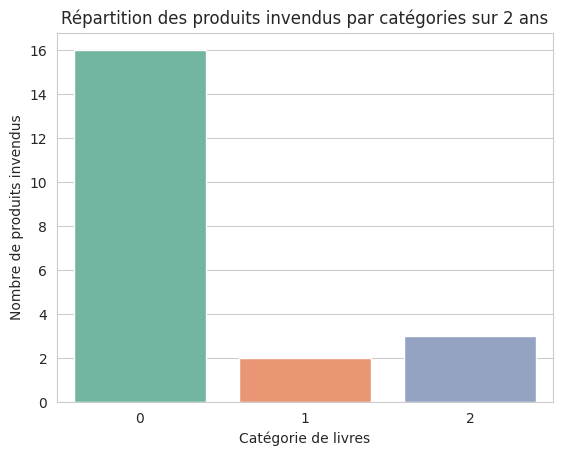

In [129]:
#Visualisation du nombre de produits invendus par catégories
df_invendus_viz = df_invendus.groupby('categ').agg({'id_prod':'nunique'})
df_invendus_viz = df_invendus_viz.sort_values('id_prod', ascending=False).reset_index()
df_invendus_viz = df_invendus_viz.rename(columns={'id_prod':'nb_produits_invendus'})

sns.barplot(data=df_invendus_viz, x='categ',y='nb_produits_invendus', hue='categ', legend=False,  palette=palette_categ)

plt.title("Répartition des produits invendus par catégories sur 2 ans")
plt.ylabel("Nombre de produits invendus")
plt.xlabel("Catégorie de livres")
plt.show()

In [34]:
#Fusion de df_transactions_customers et df_products
df_final = pd.merge(df_transactions_customers, df_products, on='id_prod', how='left')
df_final['date'] = df_final['date'].astype('datetime64[us]')

df_final.info()
print("\n")
df_final.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id_prod         687534 non-null  object        
 1   date            687534 non-null  datetime64[us]
 2   session_id      687534 non-null  object        
 3   client_id       687534 non-null  object        
 4   transaction_id  687534 non-null  object        
 5   sex             687534 non-null  object        
 6   birth           687534 non-null  int64         
 7   price           687534 non-null  float64       
 8   categ           687534 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), object(5)
memory usage: 47.2+ MB




,id_prod,date,session_id,client_id,transaction_id,sex,birth,price,categ
count,687534,687534,687534,687534,687534,687534,687534.000000,687534.000000,687534.000000
unique,3265,NaN,345505,8600,687534,2,NaN,NaN,NaN
top,1_369,NaN,s_118668,c_1609,c_3575_0_1398_2023-02-28 23:58:30.792755,m,NaN,NaN,NaN
freq,2340,NaN,14,25586,1,344841,NaN,NaN,NaN
mean,NaN,2022-03-01 21:24:00.618518,NaN,NaN,NaN,NaN,1977.817391,17.493918,0.448789
min,NaN,2021-03-01 00:01:07.843138,NaN,NaN,NaN,NaN,1929.000000,0.620000,0.000000
25%,NaN,2021-09-10 10:35:20.642323,NaN,NaN,NaN,NaN,1970.000000,8.990000,0.000000
50%,NaN,2022-02-27 06:50:25.400120,NaN,NaN,NaN,NaN,1980.000000,13.990000,0.000000
75%,NaN,2022-08-28 22:16:49.841665,NaN,NaN,NaN,NaN,1987.000000,19.080000,1.000000
max,NaN,2023-02-28 23:58:30.792755,NaN,NaN,NaN,NaN,2004.000000,300.000000,2.000000


In [35]:
#Premières lignes de df_final
df_final.head()

,id_prod,date,session_id,client_id,transaction_id,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,c_329_0_1259_2021-03-01 00:01:07.843138,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,c_664_0_1390_2021-03-01 00:02:26.047414,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,c_580_0_1352_2021-03-01 00:02:38.311413,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,c_7912_0_1458_2021-03-01 00:04:54.559692,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,c_2033_0_1358_2021-03-01 00:05:18.801198,f,1956,16.49,0


In [36]:
#Dernières lignes de df_final
df_final.tail()

,id_prod,date,session_id,client_id,transaction_id,sex,birth,price,categ
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,c_3573_1_508_2023-02-28 23:49:03.148402,f,1996,21.92,1
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,c_50_2_37_2023-02-28 23:51:29.318531,f,1994,48.99,2
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,c_488_1_695_2023-02-28 23:53:18.929676,f,1985,26.99,1
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,c_4848_0_1547_2023-02-28 23:58:00.107815,m,1953,8.99,0
687533,0_1398,2023-02-28 23:58:30.792755,s_348435,c_3575,c_3575_0_1398_2023-02-28 23:58:30.792755,f,1981,4.52,0


In [37]:
#Création de qualification des catégories et attribution d'une couleur
mapping_qualif = {0: "0- Economique",1: "1- Standard",2: "2- Premium"}

df_final['qualif']=df_final['categ'].map(mapping_qualif)

palette_qualif = {"0- Economique": "#66c2a5", "1- Standard": "#fc8d62", "2- Premium": "#8da0cb"}

## Etape 4 - Analyse du chiffre d'affaires

### 4.1 - Evolution temporelle du chiffre d'affaires

In [38]:
#Création du dataframe pour l'analyse temporelle du chiffre d'affaire
df_ca_evo = df_final.copy()
df_ca_evo['date'] = pd.to_datetime(df_ca_evo['date']).dt.date
df_ca_evo = df_ca_evo.sort_values(by='date')
df_ca_evo = df_ca_evo.groupby('date').agg({'price':'sum'}).reset_index()
df_ca_evo = df_ca_evo.rename(columns={'price':'CA_k'})
df_ca_evo['CA_k']=df_ca_evo['CA_k']/1000

#Dimensions et caractéristiques du dataframe
df_ca_evo.info()
print("\n")
df_ca_evo.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    730 non-null    object 
 1   CA_k    730 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB




,date,CA_k
count,730,730.000000
unique,730,NaN
top,2023-02-28,NaN
freq,1,NaN
mean,NaN,16.476251
std,NaN,1.407832
min,NaN,11.080750
25%,NaN,15.545260
50%,NaN,16.304720
75%,NaN,17.260515


In [39]:
#Premières lignes
df_ca_evo.head()

,date,CA_k
0,2021-03-01,16.56522
1,2021-03-02,15.48645
2,2021-03-03,15.19869
3,2021-03-04,15.19607
4,2021-03-05,17.47137


In [40]:
#Dernières lignes
df_ca_evo.tail()

,date,CA_k
725,2023-02-24,15.20789
726,2023-02-25,15.76125
727,2023-02-26,16.30472
728,2023-02-27,19.17081
729,2023-02-28,18.10515


In [41]:
#Calcul de la moyenne mobile sur 7 jours
df_ca_7j = df_ca_evo.copy()
df_ca_7j['moyenne_temp'] = df_ca_7j['CA_k'].rolling(window=7).mean()

#Calcul de la moyenne mobile sur 30 jours
df_ca_30j = df_ca_evo.copy()
df_ca_30j['moyenne_temp'] = df_ca_30j['CA_k'].rolling(window=30).mean()

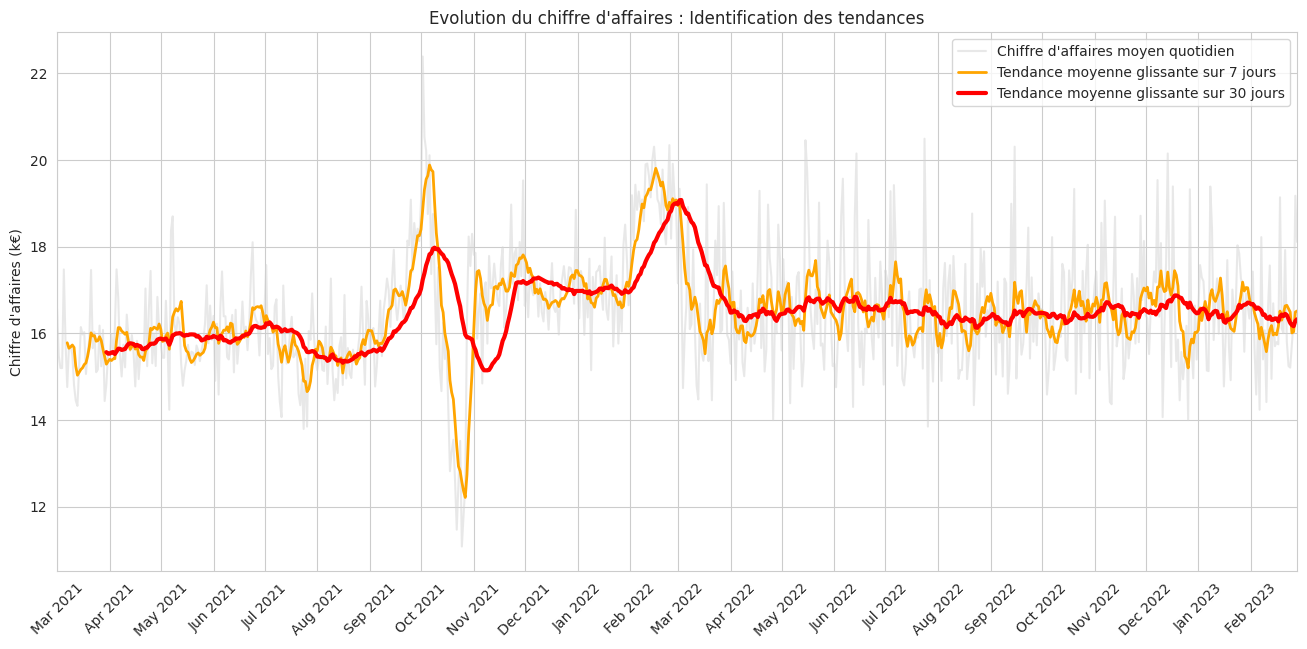

In [42]:
#Visualisation temporelle du chiffre d'affaires
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

sns.lineplot(data=df_ca_evo, x='date', y='CA_k', color='lightgray', alpha=0.5, label="Chiffre d'affaires moyen quotidien")
sns.lineplot(data=df_ca_7j, x='date', y='moyenne_temp', color='orange', linewidth=2, label='Tendance moyenne glissante sur 7 jours')
sns.lineplot(data=df_ca_30j, x='date', y='moyenne_temp', color='red', linewidth=3, label='Tendance moyenne glissante sur 30 jours')

#Mise en forme de l'axe X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().set_xlim(df_ca_evo['date'].min(), df_ca_evo['date'].max())

#Affichage du graphique
plt.title("Evolution du chiffre d'affaires : Identification des tendances")
plt.xticks(rotation=45)
plt.ylabel("Chiffre d'affaires (k€)")
plt.xlabel("")
plt.show()

### 4.2 - Répartition du chiffre d'affaires

In [43]:
#Création du dataframe pour l'analyse par catégories de livres
df_ca_qualif = df_final.copy()
df_ca_qualif = df_ca_qualif.groupby('qualif').agg({'price':'sum'})
df_ca_qualif = df_ca_qualif.sort_values(by='price', ascending=False).reset_index()
df_ca_qualif = df_ca_qualif.rename(columns={'price':'CA_M'})
df_ca_qualif['CA_M']=df_ca_qualif['CA_M']/1000000

#Dimensions et caractéristiques du dataframe
df_ca_qualif.info()
print("\n")
df_ca_qualif.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   qualif  3 non-null      object 
 1   CA_M    3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 180.0+ bytes




,qualif,CA_M
count,3,3.000000
unique,3,NaN
top,1- Standard,NaN
freq,1,NaN
mean,NaN,4.009221
std,NaN,1.083666
min,NaN,2.780275
25%,NaN,3.600003
50%,NaN,4.419731
75%,NaN,4.623694


In [44]:
#Affichage dataframe
df_ca_qualif

,qualif,CA_M
0,1- Standard,4.827657
1,0- Economique,4.419731
2,2- Premium,2.780275


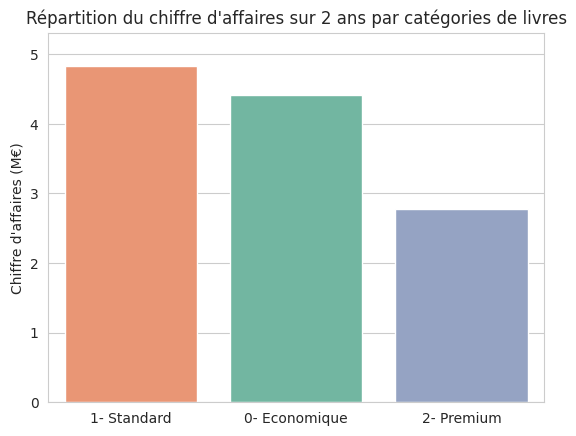

In [130]:
#Visualisation histogramme de la répartition du CA par catégories
sns.barplot(data=df_ca_qualif, x='qualif',y='CA_M', hue='qualif', legend=False, palette=palette_qualif)
plt.ylim(0,max(df_ca_qualif['CA_M']*1.1))
plt.title("Répartition du chiffre d'affaires sur 2 ans par catégories de livres")
plt.ylabel("Chiffre d'affaires (M€)")
plt.xlabel("")
plt.show()

### 4.3 - Le nombre de clients

In [46]:
#Création du dataframe pour l'analyse du nombre de clients par mois
df_clients = df_final.copy()
df_clients['mois'] = pd.to_datetime(df_clients['date']).dt.to_period('M')
df_clients['mois'] = df_clients['mois'].dt.to_timestamp()
df_clients = df_clients.groupby('mois').agg({'client_id':'nunique'})
df_clients = df_clients.sort_values(by='mois').reset_index()
df_clients['mois'] = df_clients['mois'].dt.strftime('%b %Y')
df_clients = df_clients.rename(columns={'client_id':'nb_clients'})

#Dimensions et caractéristiques du dataframe
df_clients.info()
print("\n")
df_clients.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mois        24 non-null     object
 1   nb_clients  24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes




,mois,nb_clients
count,24,24.000000
unique,24,NaN
top,Mar 2021,NaN
freq,1,NaN
mean,NaN,5759.375000
std,NaN,120.386628
min,NaN,5587.000000
25%,NaN,5675.500000
50%,NaN,5743.500000
75%,NaN,5813.750000


In [47]:
#Premières lignes
df_clients.head()

,mois,nb_clients
0,Mar 2021,5676
1,Apr 2021,5674
2,May 2021,5644
3,Jun 2021,5659
4,Jul 2021,5672


In [48]:
#Dernières lignes
df_clients.tail()

,mois,nb_clients
19,Oct 2022,5755
20,Nov 2022,5749
21,Dec 2022,5765
22,Jan 2023,5828
23,Feb 2023,5587


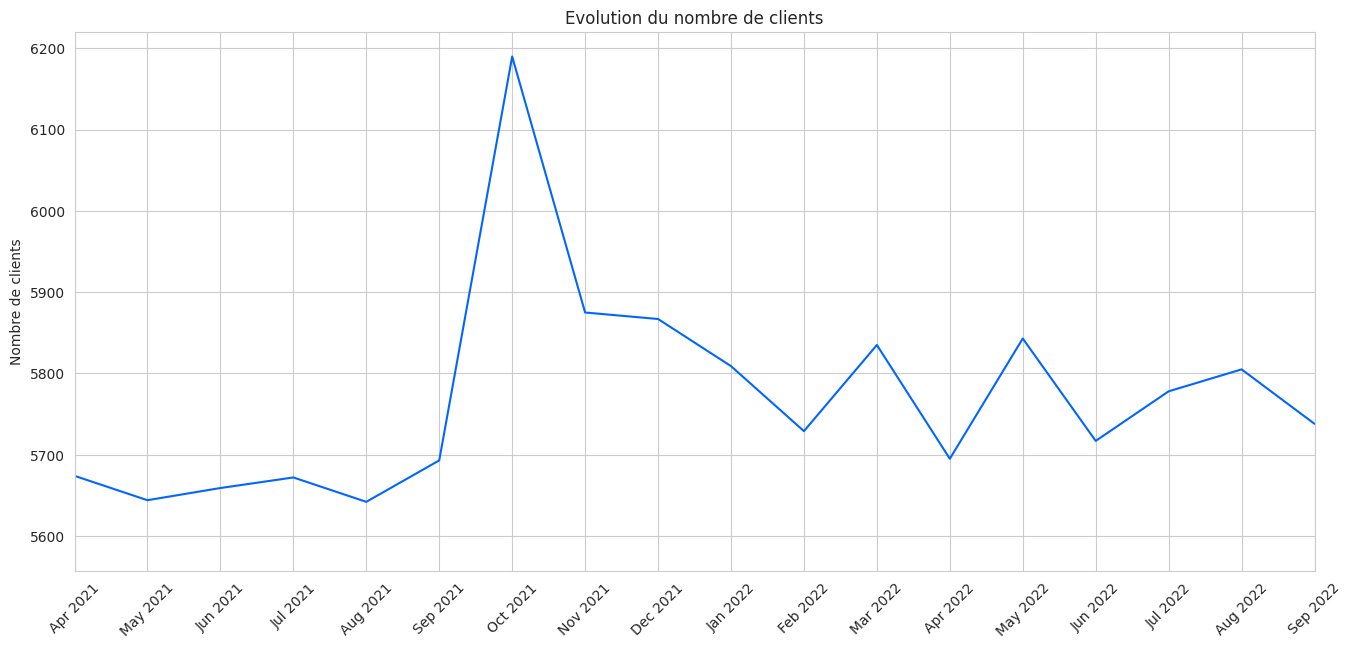

In [49]:
#Visualisation du nombre de clients par mois
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_clients, x='mois', y='nb_clients', color='#0066FF')
plt.gca().set_xlim(df_clients['mois'].min(), df_clients['mois'].max())
plt.xticks(rotation=45)
plt.title("Evolution du nombre de clients")
plt.ylabel("Nombre de clients")
plt.xlabel("")
plt.show()

### 4.4 - Evolution du nombre de transactions

In [50]:
#création du dataframe pour l'analyse du nombre de transaction par mois
df_transactions = df_final.copy()
df_transactions['mois'] = pd.to_datetime(df_transactions['date']).dt.to_period('M')
df_transactions['mois'] = df_transactions['mois'].dt.to_timestamp()
df_transactions=df_transactions.groupby('mois').agg({'transaction_id':'count'})
df_transactions=df_transactions.sort_values(by='mois').reset_index()
df_transactions['mois'] = df_transactions['mois'].dt.strftime('%b %Y')
df_transactions = df_transactions.rename(columns={'transaction_id':'nb_transactions'})

#Dimensions et caractéristiques du dataframe
df_transactions.info()
print("\n")
df_transactions.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   mois             24 non-null     object
 1   nb_transactions  24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes




,mois,nb_transactions
count,24,24.000000
unique,24,NaN
top,Mar 2021,NaN
freq,1,NaN
mean,NaN,28647.250000
std,NaN,1879.723621
min,NaN,24738.000000
25%,NaN,28300.750000
50%,NaN,28582.000000
75%,NaN,29405.750000


In [51]:
#Premières lignes
df_transactions.head()

,mois,nb_transactions
0,Mar 2021,28601
1,Apr 2021,28443
2,May 2021,28285
3,Jun 2021,26850
4,Jul 2021,24738


In [52]:
#Dernières lignes
df_transactions.tail()

,mois,nb_transactions
19,Oct 2022,28964
20,Nov 2022,28563
21,Dec 2022,28619
22,Jan 2023,28938
23,Feb 2023,25545


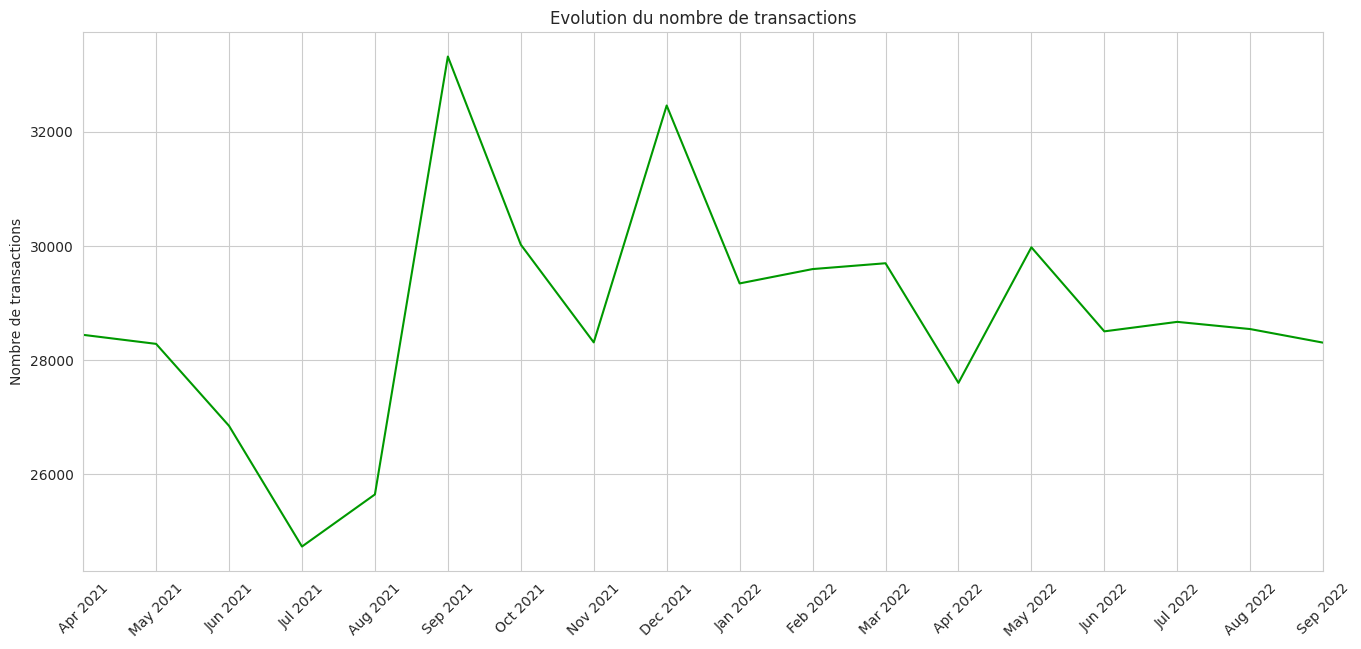

In [53]:
#Visualisation de l'évolution du nombre de transactions
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_transactions, x='mois', y='nb_transactions', color='#009900')
plt.gca().set_xlim(df_transactions['mois'].min(), df_transactions['mois'].max())
plt.xticks(rotation=45)
plt.title("Evolution du nombre de transactions")
plt.ylabel("Nombre de transactions")
plt.xlabel("")
plt.show()

### 4.5 - Evolution du nombre de produits vendus

In [54]:
#Création du dataframe pour l'analyse
df_produits = df_final.copy()
df_produits['mois'] = pd.to_datetime(df_produits['date']).dt.to_period('M')
df_produits['mois'] = df_produits['mois'].dt.to_timestamp()
df_produits=df_produits.groupby('mois').agg({'id_prod':'count'})
df_produits=df_produits.sort_values(by='mois').reset_index()
df_produits['mois'] = df_produits['mois'].dt.strftime('%b %Y')
df_produits = df_produits.rename(columns={'id_prod':'nb_produits'})

#Dimensions et caractéristiques du dataframe
df_produits.info()
print("\n")
df_produits.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   mois         24 non-null     object
 1   nb_produits  24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes




,nb_produits
count,24.000000
mean,28647.250000
std,1879.723621
min,24738.000000
25%,28300.750000
50%,28582.000000
75%,29405.750000
max,33314.000000


In [55]:
#Premières lignes
df_produits.head()

,mois,nb_produits
0,Mar 2021,28601
1,Apr 2021,28443
2,May 2021,28285
3,Jun 2021,26850
4,Jul 2021,24738


In [56]:
#Dernières lignes
df_produits.tail()

,mois,nb_produits
19,Oct 2022,28964
20,Nov 2022,28563
21,Dec 2022,28619
22,Jan 2023,28938
23,Feb 2023,25545


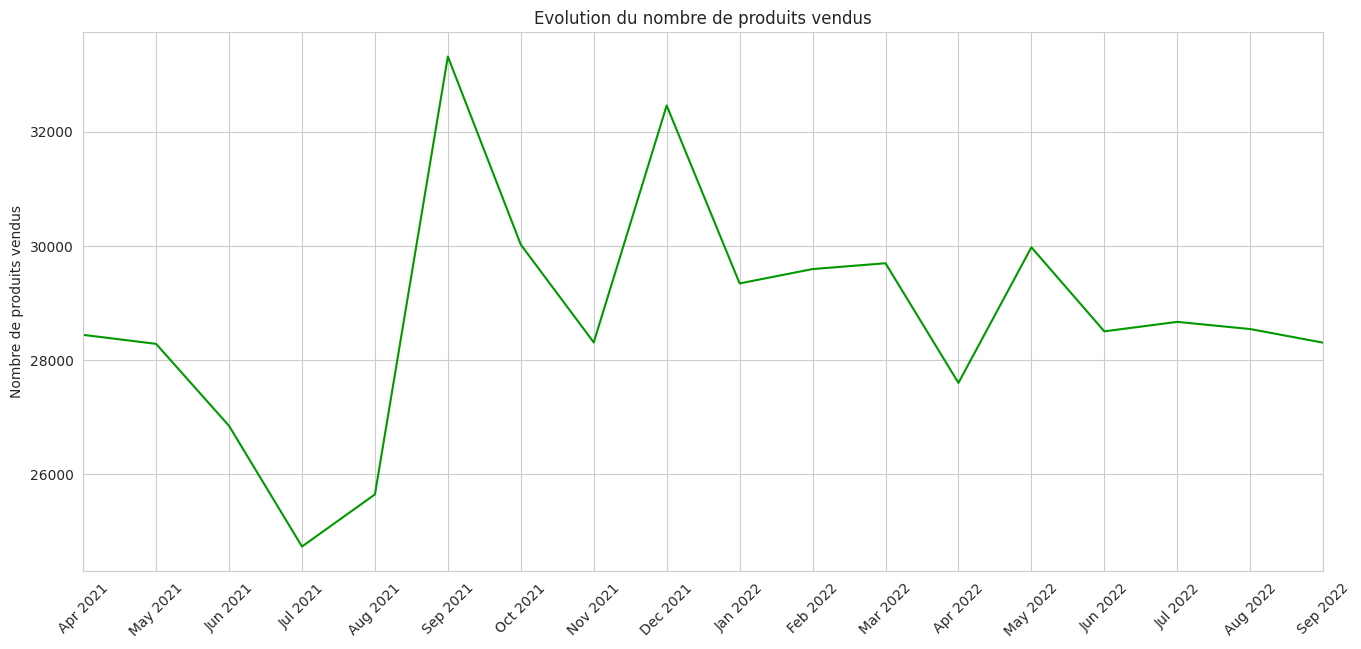

In [57]:
#Visualisation de l'évolution du nombre de produits vendus
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_produits, x='mois', y='nb_produits', color='#009900')
plt.gca().set_xlim(df_transactions['mois'].min(), df_transactions['mois'].max())
plt.xticks(rotation=45)
plt.title("Evolution du nombre de produits vendus")
plt.ylabel("Nombre de produits vendus")
plt.xlabel("")
plt.show()

Chaque transaction correspond à un et un seul produit.

### 4.6 - Comparaison des évolutions du nombre de clients et de produits vendus

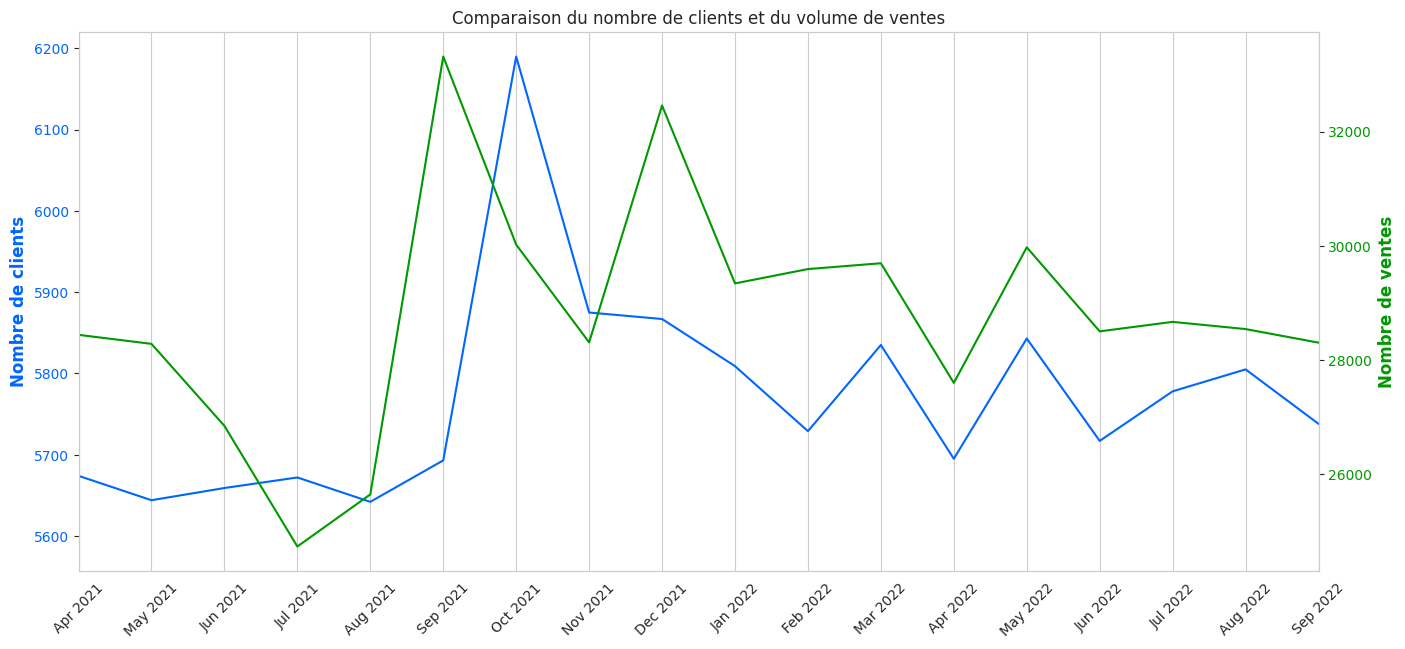

In [58]:
#Visuel comparaison des évolutions du nombre de clients et de produits vendus
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

ax1=sns.lineplot(data=df_clients, x='mois', y='nb_clients', color='#0066FF')
ax1.set_xlabel("")
ax1.set_ylabel("Nombre de clients", color='#0066FF', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#0066FF')

ax2=ax1.twinx()
sns.lineplot(data=df_produits, x='mois', y='nb_produits', color='#009900')
ax2.set_ylabel("Nombre de ventes", color='#009900', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#009900')

ax1.grid(False,axis='y')
ax2.grid(False)

plt.gca().set_xlim(df_clients['mois'].min(), df_clients['mois'].max())
ax1.tick_params(axis='x', rotation=45)


plt.title("Comparaison du nombre de clients et du volume de ventes")
plt.show()

### 4.7 - Répartition du nombre de produits vendus par catégories

In [59]:
#Création du dataframe pour analyse
df_produits_qualif = df_final.copy()
df_produits_qualif = df_produits_qualif.groupby('qualif').agg({'id_prod':'count'})
df_produits_qualif = df_produits_qualif.sort_values(by='id_prod', ascending=False).reset_index()
df_produits_qualif = df_produits_qualif.rename(columns={'id_prod':'nb_produits'})

In [60]:
#Aperçu dataframe
df_produits_qualif

,qualif,nb_produits
0,0- Economique,415459
1,1- Standard,235592
2,2- Premium,36483


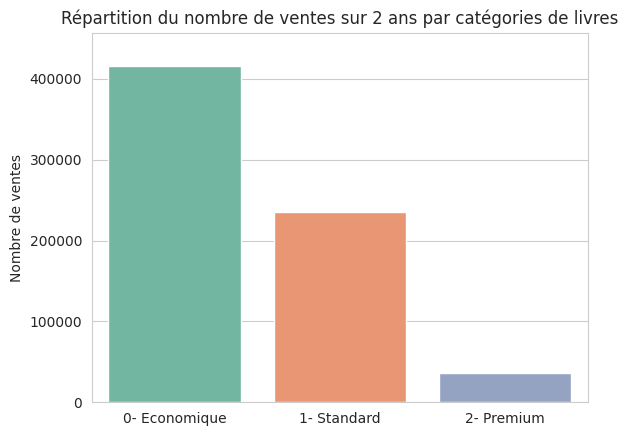

In [131]:
#Visualisation histogramme de la répartition du nombre de produits vendus par catégories
sns.barplot(data=df_produits_qualif, x='qualif',y='nb_produits', hue='qualif', legend=False, palette=palette_qualif)
plt.ylim(0,max(df_produits_qualif['nb_produits']*1.1))
plt.title("Répartition du nombre de ventes sur 2 ans par catégories de livres")
plt.ylabel("Nombre de ventes")
plt.xlabel("")
plt.show()

## Etape 5 - Analyse des tops références

### 5.1 - Top CA

In [133]:
#Création du dataframe pour l'analyse
df_top_ca=df_final.copy()
df_top_ca=df_top_ca.groupby(['qualif','id_prod']).agg({'price':'sum','transaction_id':'count'})
df_top_ca=df_top_ca.rename(columns={'price':'CA','transaction_id':'nb_ventes'})
df_top_ca=df_top_ca.sort_values(['CA','nb_ventes'], ascending=[False,False]).reset_index()
df_top_ca['CA_k']=round(df_top_ca['CA']/1000)
df_top_ca=df_top_ca.head(10)

In [134]:
#Affichage du dataframe
df_top_ca

,qualif,id_prod,CA,nb_ventes,CA_k
0,2- Premium,2_159,94893.50,650,95.0
1,2- Premium,2_135,69334.95,1005,69.0
2,2- Premium,2_112,65407.76,968,65.0
3,2- Premium,2_102,60736.78,1027,61.0
4,2- Premium,2_209,56971.86,814,57.0
5,1- Standard,1_395,56617.47,1953,57.0
6,1- Standard,1_369,56136.60,2340,56.0
7,2- Premium,2_110,53846.25,865,54.0
8,1- Standard,1_383,53834.43,1857,54.0
9,1- Standard,1_414,53522.18,2246,54.0


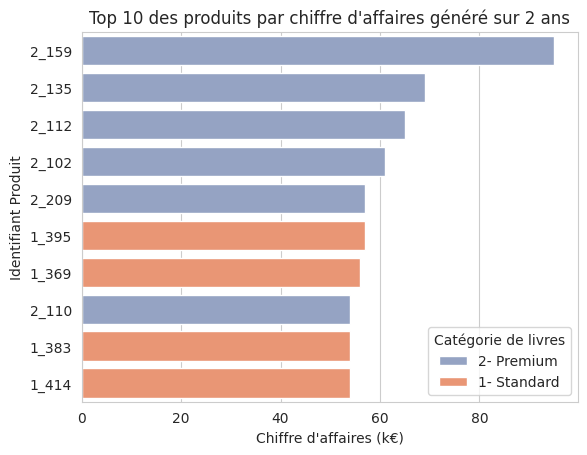

In [140]:

#Visualisation du top CA global
sns.set_style("whitegrid")

ax1=sns.barplot(data=df_top_ca, x='CA_k', y='id_prod', hue='qualif', palette=palette_qualif)
plt.legend(title='Catégorie de livres')

plt.title("Top 10 des produits par chiffre d'affaires généré sur 2 ans")
plt.xlabel("Chiffre d'affaires (k€)")
plt.ylabel("Identifiant Produit")
plt.show()

### 5.2 - Top quantités venues

In [65]:
#Création du dataframe pour l'analyse
df_top_nb=df_final.copy()
df_top_nb=df_top_nb.groupby(['qualif','id_prod']).agg({'transaction_id':'count','price':'sum'})
df_top_nb=df_top_nb.rename(columns={'transaction_id':'nb_ventes','price':'CA'})
df_top_nb=df_top_nb.sort_values(['nb_ventes','CA'], ascending=[False,False]).reset_index()
df_top_nb=df_top_nb.head(10)

In [66]:
#Affichage du dataframe
df_top_nb

,qualif,id_prod,nb_ventes,CA
0,1- Standard,1_369,2340,56136.60
1,1- Standard,1_417,2269,47626.31
2,1- Standard,1_414,2246,53522.18
3,1- Standard,1_498,2202,51460.74
4,1- Standard,1_425,2163,36749.37
5,1- Standard,1_403,2040,36699.60
6,1- Standard,1_413,2036,36627.64
7,1- Standard,1_412,2014,33533.10
8,1- Standard,1_406,2003,49694.43
9,1- Standard,1_407,2001,31995.99


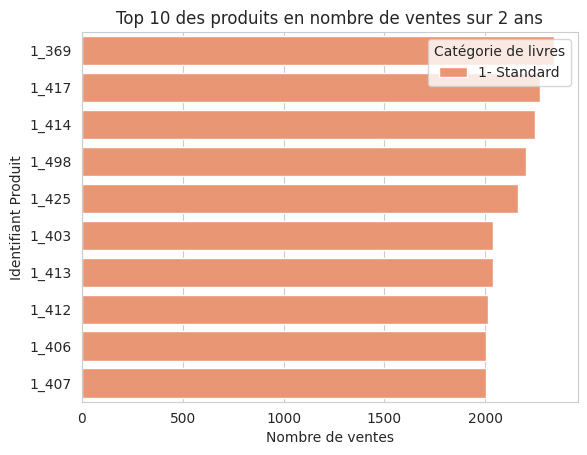

In [141]:
#Visualisation du top ventes global
sns.set_style("whitegrid")

sns.barplot(data=df_top_nb, x='nb_ventes', y='id_prod', hue='qualif', palette=palette_qualif)
plt.legend(title='Catégorie de livres')

plt.title("Top 10 des produits en nombre de ventes sur 2 ans")
plt.xlabel("Nombre de ventes")
plt.ylabel("Identifiant Produit")
plt.show()

##Etape 6 - Analyse des flops références

### 6.1 - Flop CA

In [68]:
#Création du dataframe pour l'analyse
df_flop_ca=df_final.copy()
df_flop_ca=df_flop_ca.groupby(['qualif','id_prod']).agg({'price':'sum','transaction_id':'count'})
df_flop_ca=df_flop_ca.rename(columns={'price':'CA','transaction_id':'nb_ventes'})
df_flop_ca=df_flop_ca.sort_values(['CA','nb_ventes'], ascending=[True,True]).reset_index()
df_flop_ca=df_flop_ca.head(10)

In [69]:
#Affichage du dataframe
df_flop_ca

,qualif,id_prod,CA,nb_ventes
0,0- Economique,0_1539,0.99,1
1,0- Economique,0_1284,1.38,1
2,0- Economique,0_1653,1.98,2
3,0- Economique,0_1601,1.99,1
4,0- Economique,0_541,1.99,1
5,0- Economique,0_807,1.99,1
6,0- Economique,0_1728,2.27,1
7,0- Economique,0_1498,2.48,1
8,0- Economique,0_898,2.54,2
9,0- Economique,0_1840,2.56,2


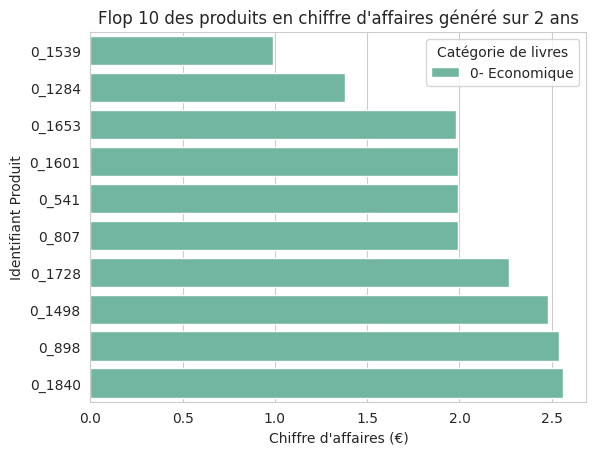

In [143]:
#Visualisation du flop CA global

sns.set_style("whitegrid")

sns.barplot(data=df_flop_ca, x='CA', y='id_prod', hue='qualif', palette=palette_qualif)
plt.legend(title='Catégorie de livres')

plt.title("Flop 10 des produits en chiffre d'affaires généré sur 2 ans")
plt.ylabel("Identifiant Produit")
plt.xlabel("Chiffre d'affaires (€)")
plt.show()

### 6.2 - Flop quantités vendues

In [71]:
#Création du dataframe pour l'analyse
df_flop_nb=df_final.copy()
df_flop_nb=df_flop_nb.groupby(['qualif','id_prod']).agg({'transaction_id':'count','price':'sum'})
df_flop_nb=df_flop_nb.rename(columns={'transaction_id':'nb_ventes','price':'CA'})
df_flop_nb=df_flop_nb.sort_values(['nb_ventes','CA'], ascending=[True,True]).reset_index()
df_flop_nb=df_flop_nb.head(10)

In [72]:
#Affichage du dataframe
df_flop_nb

,qualif,id_prod,nb_ventes,CA
0,0- Economique,0_1539,1,0.99
1,0- Economique,0_1284,1,1.38
2,0- Economique,0_1601,1,1.99
3,0- Economique,0_541,1,1.99
4,0- Economique,0_807,1,1.99
5,0- Economique,0_1728,1,2.27
6,0- Economique,0_1498,1,2.48
7,0- Economique,0_1151,1,2.99
8,0- Economique,0_1379,1,2.99
9,0- Economique,0_1683,1,2.99


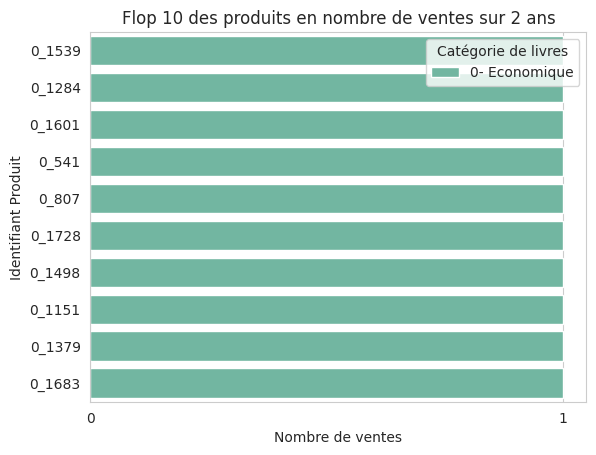

In [146]:
#Visualisation du flop 10 des quantités produits par an
sns.set_style("whitegrid")

ax=sns.barplot(data=df_flop_nb, x='nb_ventes', y='id_prod', hue='qualif', palette=palette_qualif)
plt.legend(title='Catégorie de livres')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.title("Flop 10 des produits en nombre de ventes sur 2 ans")
plt.xlabel("Nombre de ventes")
plt.ylabel("Identifiant Produit")
plt.show()

## Etape 7 - Analyse approfondie des références

### 7.1 - Prix

In [74]:
#Moyenne des prix par catégories de livres
df_prix = df_final.copy()
df_prix = df_prix.groupby('qualif').agg({'id_prod':'nunique','price':'mean'})
df_prix = df_prix.sort_values('price', ascending=False).reset_index()
df_prix = df_prix.rename(columns={'id_prod':'nb_produits','price':'prix_moyen'})
df_prix

,qualif,nb_produits,prix_moyen
0,2- Premium,236,76.207412
1,1- Standard,737,20.491600
2,0- Economique,2292,10.638188


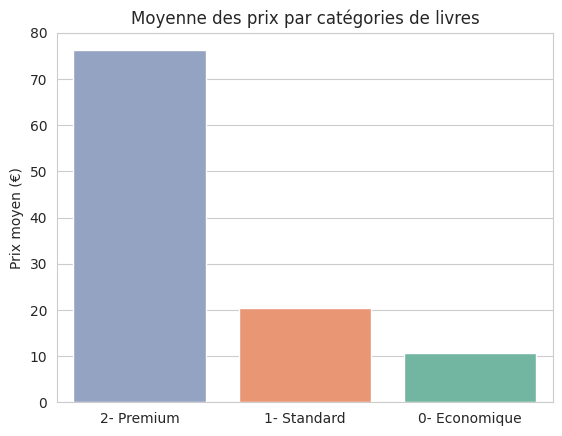

In [75]:
#Visualisation des moyennes de prix
sns.set_style("whitegrid")
sns.barplot(data=df_prix, x='qualif', y='prix_moyen', hue='qualif', palette=palette_qualif)
plt.title("Moyenne des prix par catégories de livres")
plt.ylabel("Prix moyen (€)")
plt.xlabel("")
plt.show()

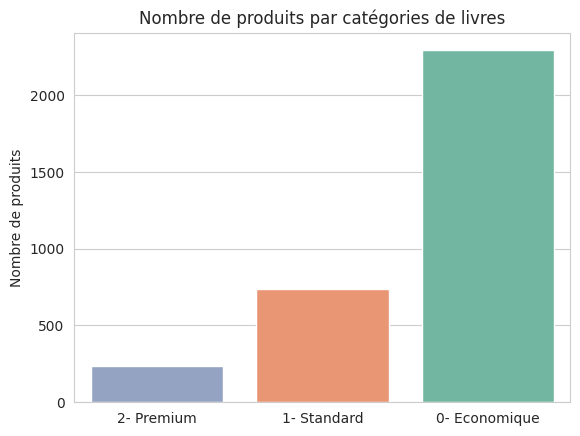

In [76]:
#Visualisation du nombre de produits par gamme
sns.set_style("whitegrid")
sns.barplot(data=df_prix, x='qualif', y='nb_produits', hue='qualif', palette=palette_qualif)
plt.title("Nombre de produits par catégories de livres")
plt.ylabel("Nombre de produits")
plt.xlabel("")
plt.show()

### 7.2 - Ventes

Text(0.5, 0, '')

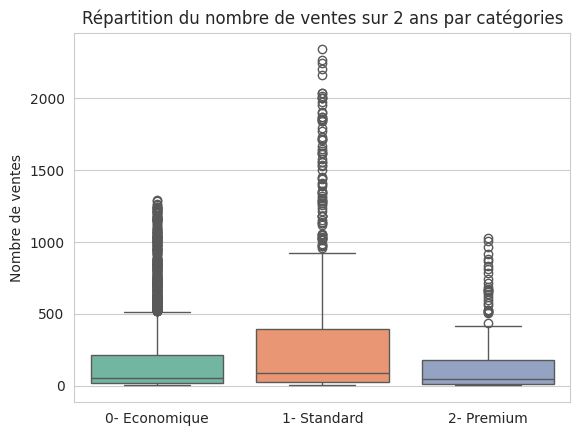

In [147]:
#Analyse des ventes par catégorie
df_ventes=df_final.copy()
df_ventes=df_ventes.groupby(['qualif', 'id_prod']).agg({'transaction_id': 'count'}).reset_index()
df_ventes=df_ventes.rename(columns={'transaction_id':'nb_ventes'})

sns.boxplot(data=df_ventes, x='qualif', y='nb_ventes',hue='qualif',palette=palette_qualif)
plt.title("Répartition du nombre de ventes sur 2 ans par catégories")
plt.ylabel("Nombre de ventes")
plt.xlabel("")

In [78]:
#Détail par catégorie
df_ventes.groupby('qualif')['nb_ventes'].describe()

,count,mean,std,min,25%,50%,75%,max
qualif,,,,,,,,
0- Economique,2292.0,181.264834,275.445990,1.0,15.00,51.0,214.00,1292.0
1- Standard,737.0,319.663501,487.260212,2.0,26.00,89.0,391.00,2340.0
2- Premium,236.0,154.588983,229.946961,1.0,13.75,45.0,179.25,1027.0


In [79]:
# Calcul des quartiles et de l'IQR par catégorie
q1 = df_ventes.groupby('qualif')['nb_ventes'].transform('quantile', 0.25)
q3 = df_ventes.groupby('qualif')['nb_ventes'].transform('quantile', 0.75)
iqr = q3 - q1

# Définition des bornes
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

# Identification des outliers
df_outliers = df_ventes[(df_ventes['nb_ventes'] < borne_basse) | (df_ventes['nb_ventes'] > borne_haute)]
df_outliers = df_outliers.sort_values('nb_ventes', ascending=False)

# Affichage des 10 plus gros succès (outliers supérieurs)
df_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393 entries, 2591 to 3046
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   qualif     393 non-null    object
 1   id_prod    393 non-null    object
 2   nb_ventes  393 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 12.3+ KB


In [80]:
#Premières lignes
df_outliers.head(10)

,qualif,id_prod,nb_ventes
2591,1- Standard,1_369,2340
2644,1- Standard,1_417,2269
2641,1- Standard,1_414,2246
2733,1- Standard,1_498,2202
2653,1- Standard,1_425,2163
2629,1- Standard,1_403,2040
2640,1- Standard,1_413,2036
2639,1- Standard,1_412,2014
2632,1- Standard,1_406,2003
2633,1- Standard,1_407,2001


In [81]:
#Dernières lignes
df_outliers.tail(10)

,qualif,id_prod,nb_ventes
171,0- Economique,0_1156,520
31,0- Economique,0_1028,518
119,0- Economique,0_1108,518
3125,2- Premium,2_185,518
167,0- Economique,0_1152,517
143,0- Economique,0_1130,516
3124,2- Premium,2_184,513
3102,2- Premium,2_164,511
3121,2- Premium,2_181,503
3046,2- Premium,2_113,433


In [82]:
#Outliers par catégories
df_outliers.groupby('qualif').agg({'nb_ventes':'count'})

,nb_ventes
qualif,
0- Economique,280
1- Standard,84
2- Premium,29


### 7.3 - Top clients

In [83]:
#Top des clients
df_top_clients=df_final.copy()
df_top_clients=df_top_clients.groupby('client_id').agg({'transaction_id':'count','price':'sum'}).reset_index()
df_top_clients=df_top_clients.rename(columns={'transaction_id':'nb_ventes','price':'CA'})

#Caractéristique du dataframe
df_top_clients.info()
print("\n")
df_top_clients.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   client_id  8600 non-null   object 
 1   nb_ventes  8600 non-null   int64  
 2   CA         8600 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 201.7+ KB




,client_id,nb_ventes,CA
count,8600,8600.000000,8600.000000
unique,8600,NaN,NaN
top,c_999,NaN,NaN
freq,1,NaN,NaN
mean,NaN,79.945814,1398.565477
std,NaN,313.532311,5202.771679
min,NaN,1.000000,6.310000
25%,NaN,28.000000,562.730000
50%,NaN,52.000000,1045.695000
75%,NaN,97.000000,1797.720000


In [84]:
#Top 10 clients en CA
df_top_clients=df_top_clients.sort_values('CA', ascending=False).reset_index(drop=True)
df_top_clients['type']=np.where(df_top_clients['CA']>10000, 'BtoB', 'BtoC')
df_top_clients.head(10)

,client_id,nb_ventes,CA,type
0,c_1609,25586,326039.89,BtoB
1,c_4958,5222,290227.03,BtoB
2,c_6714,9199,153918.60,BtoB
3,c_3454,6793,114110.57,BtoB
4,c_1570,370,5285.82,BtoC
5,c_3263,403,5276.87,BtoC
6,c_2140,405,5260.18,BtoC
7,c_2899,105,5214.05,BtoC
8,c_7319,371,5155.77,BtoC
9,c_7959,372,5135.75,BtoC


### 7.4 - Clients BtoB

In [85]:
#Dataframe répartition CA BtoB vs BtoC
df_type_clients=df_top_clients.copy()
df_type_clients=df_type_clients.groupby('type').agg({'client_id':'nunique','nb_ventes':'sum','CA':'sum'})
df_type_clients=df_type_clients.rename(columns={'client_id':'nb_clients'})
df_type_clients['CA_M']=round(df_type_clients['CA']/1000000,2)
df_type_clients=df_type_clients.sort_values('CA', ascending=False).reset_index()
df_type_clients

,type,nb_clients,nb_ventes,CA,CA_M
0,BtoC,8596,640734,11143367.01,11.14
1,BtoB,4,46800,884296.09,0.88


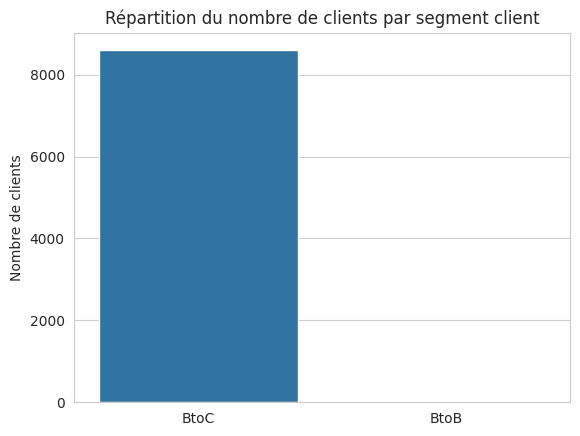

In [86]:
#Visuel barres répartition nb_clients BtoB vs BtoC
sns.set_style("whitegrid")

sns.barplot(data=df_type_clients, x='type', y='nb_clients', hue='type', palette='tab10')
plt.title("Répartition du nombre de clients par segment client")
plt.ylabel("Nombre de clients")
plt.xlabel("")
plt.show()

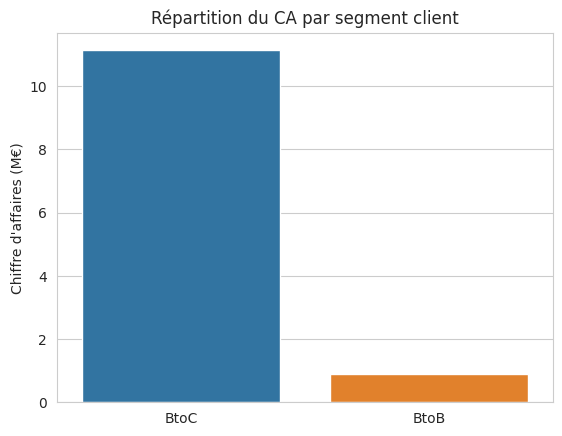

In [87]:
#Visuel barres répartition CA BtoB vs BtoC
sns.set_style("whitegrid")

sns.barplot(data=df_type_clients, x='type', y='CA_M', hue='type', palette='tab10')
plt.title("Répartition du CA par segment client")
plt.ylabel("Chiffre d'affaires (M€)")
plt.xlabel("")
plt.show()

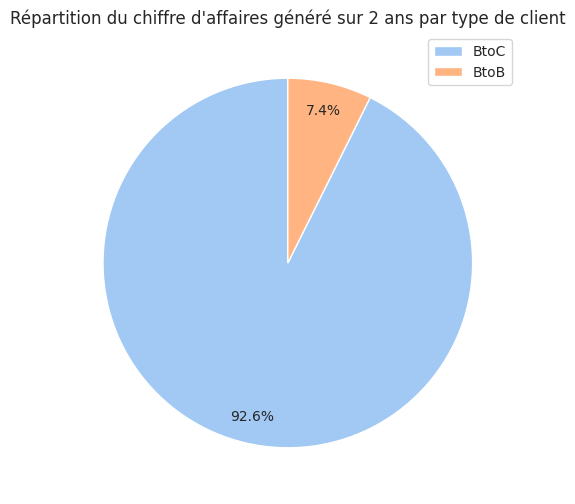

In [150]:
#Visuel camembert répartition CA BtoB vs BtoC
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

plt.pie(df_type_clients['CA'],autopct='%1.1f%%',colors=sns.color_palette('pastel'),startangle=90,pctdistance=0.85)
plt.legend(labels=df_type_clients['type'],loc='upper right')


plt.title("Répartition du chiffre d'affaires généré sur 2 ans par type de client")
plt.show()

In [89]:
#Top 10 en CA
df_top_10=df_top_clients.sort_values('CA', ascending=False).reset_index(drop=True).head(10)
df_top_10['CA_k']=round(df_top_10['CA']/1000)
df_top_10

,client_id,nb_ventes,CA,type,CA_k
0,c_1609,25586,326039.89,BtoB,326.0
1,c_4958,5222,290227.03,BtoB,290.0
2,c_6714,9199,153918.60,BtoB,154.0
3,c_3454,6793,114110.57,BtoB,114.0
4,c_1570,370,5285.82,BtoC,5.0
5,c_3263,403,5276.87,BtoC,5.0
6,c_2140,405,5260.18,BtoC,5.0
7,c_2899,105,5214.05,BtoC,5.0
8,c_7319,371,5155.77,BtoC,5.0
9,c_7959,372,5135.75,BtoC,5.0


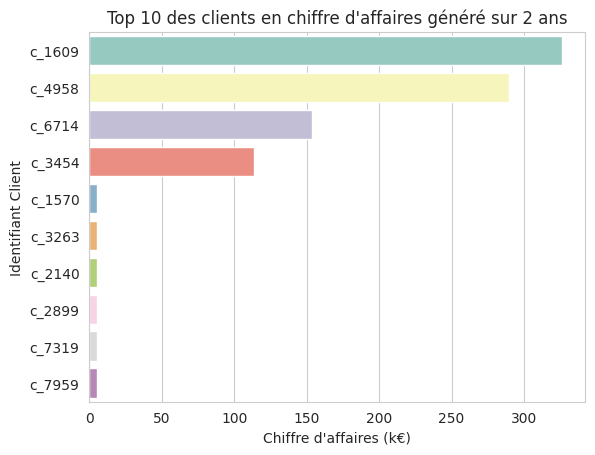

In [148]:
#Visualisation du top 10 clients
sns.set_style("whitegrid")

sns.barplot(data=df_top_10, x='CA_k', y='client_id', hue='client_id', palette='Set3')

plt.title("Top 10 des clients en chiffre d'affaires généré sur 2 ans")
plt.ylabel("Identifiant Client")
plt.xlabel("Chiffre d'affaires (k€)")
plt.show()

In [91]:
#Isolement des clients b to b
df_btob=df_top_clients.copy()
df_btob=df_btob.loc[df_btob['CA']>10000].reset_index(drop=True)
df_btob

,client_id,nb_ventes,CA,type
0,c_1609,25586,326039.89,BtoB
1,c_4958,5222,290227.03,BtoB
2,c_6714,9199,153918.60,BtoB
3,c_3454,6793,114110.57,BtoB


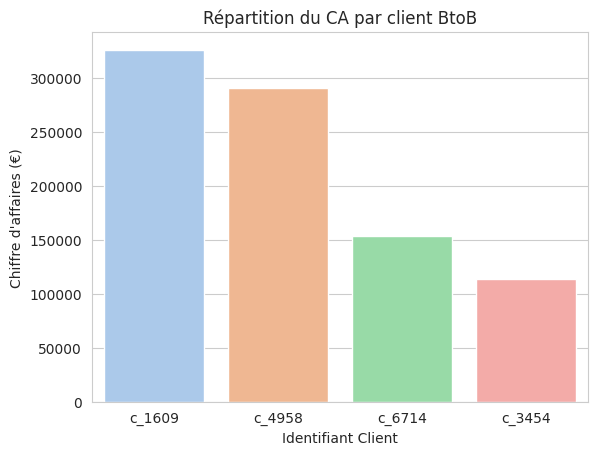

In [92]:
#Visuel de la répartition CA entre les BtoB
sns.set_style("whitegrid")

sns.barplot(data=df_btob, x='client_id', y='CA', hue='client_id', palette='pastel')
plt.title("Répartition du CA par client BtoB")
plt.ylabel("Chiffre d'affaires (€)")
plt.xlabel("Identifiant Client")
plt.show()

### 7.5 - Courbe de Lorenz

In [93]:
#Isolement des clients BtoC
df_btoc=df_top_clients.copy()
df_btoc=df_btoc.loc[df_btoc['CA']<=10000]
df_btoc.head()

,client_id,nb_ventes,CA,type
4,c_1570,370,5285.82,BtoC
5,c_3263,403,5276.87,BtoC
6,c_2140,405,5260.18,BtoC
7,c_2899,105,5214.05,BtoC
8,c_7319,371,5155.77,BtoC


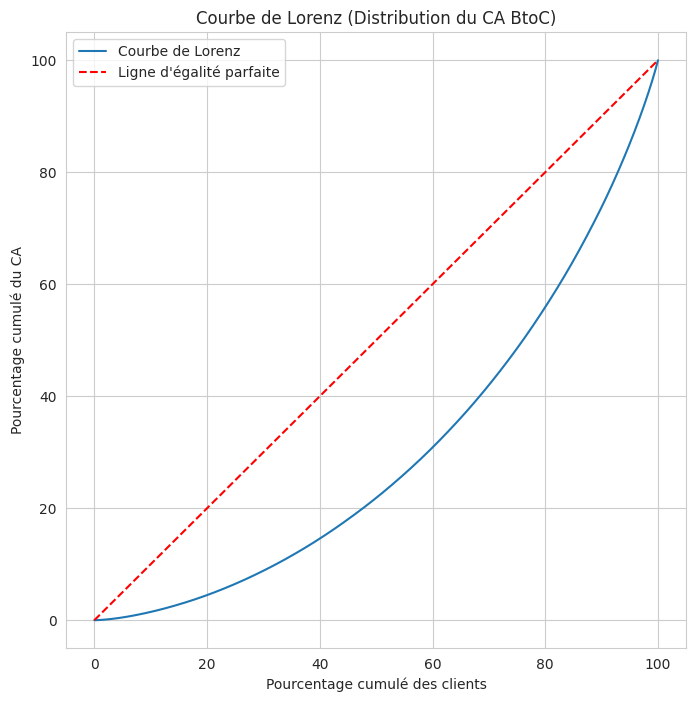

In [94]:
#Tri des données par ordre croissant
df_btoc = df_btoc.sort_values('CA', ascending=True).reset_index(drop=True)

#Calcul des cumuls en pourcentage
n = len(df_btoc)
ca_cumule = df_btoc['CA'].cumsum().values
ca_total = ca_cumule[-1]

y_lorenz = ca_cumule / ca_total
x_lorenz = (np.arange(1, n + 1)) / n

#Ajout du point (0,0)
x_lorenz = np.insert(x_lorenz, 0, 0)
y_lorenz = np.insert(y_lorenz, 0, 0)

#Visualisation
plt.figure(figsize=(8, 8))
plt.plot(x_lorenz * 100, y_lorenz * 100, label='Courbe de Lorenz')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Ligne d\'égalité parfaite')

plt.title('Courbe de Lorenz (Distribution du CA BtoC)')
plt.xlabel('Pourcentage cumulé des clients')
plt.ylabel('Pourcentage cumulé du CA')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
# Calcul de l'aire sous la courbe de Lorenz
AUC = np.trapz(y_lorenz, x_lorenz)

# Le coefficient de Gini
gini = (0.5 - AUC) / 0.5

print(f"Le coefficient de Gini pour le segment BtoC est de : {gini:.3f}")

Le coefficient de Gini pour le segment BtoC est de : 0.398


/tmp/ipython-input-1161181380.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC = np.trapz(y_lorenz, x_lorenz)


## Etape 9 - Analyse des corélations et autres tests statistiques

In [96]:
#Création d'un dataframe BtoC global
list_btob = df_btob['client_id'].unique()

df_final_btoc = df_final.copy()
df_final_btoc = df_final_btoc[~df_final['client_id'].isin(list_btob)]
df_final_btoc['age'] = 2026 - df_final_btoc['birth']
df_final_btoc['age'].astype(int)

df_final_btoc.info()
print("\n")
df_final_btoc.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 640734 entries, 0 to 687533
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id_prod         640734 non-null  object        
 1   date            640734 non-null  datetime64[us]
 2   session_id      640734 non-null  object        
 3   client_id       640734 non-null  object        
 4   transaction_id  640734 non-null  object        
 5   sex             640734 non-null  object        
 6   birth           640734 non-null  int64         
 7   price           640734 non-null  float64       
 8   categ           640734 non-null  int64         
 9   qualif          640734 non-null  object        
 10  age             640734 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), object(6)
memory usage: 58.7+ MB




,id_prod,date,session_id,client_id,transaction_id,sex,birth,price,categ,qualif,age
count,640734,640734,640734,640734,640734,640734,640734.000000,640734.000000,640734.000000,640734,640734.000000
unique,3262,NaN,322466,8596,640734,2,NaN,NaN,NaN,3,NaN
top,1_369,NaN,s_118668,c_2140,c_3575_0_1398_2023-02-28 23:58:30.792755,f,NaN,NaN,NaN,0- Economique,NaN
freq,2205,NaN,14,405,1,333494,NaN,NaN,NaN,387281,NaN
mean,NaN,2022-03-01 19:54:48.993831,NaN,NaN,NaN,NaN,1977.792024,17.391565,0.446833,NaN,48.207976
min,NaN,2021-03-01 00:01:07.843138,NaN,NaN,NaN,NaN,1929.000000,0.620000,0.000000,NaN,22.000000
25%,NaN,2021-09-10 12:57:21.151825,NaN,NaN,NaN,NaN,1971.000000,8.990000,0.000000,NaN,39.000000
50%,NaN,2022-02-27 03:35:19.841475,NaN,NaN,NaN,NaN,1979.000000,13.990000,0.000000,NaN,47.000000
75%,NaN,2022-08-28 20:52:44.320891,NaN,NaN,NaN,NaN,1987.000000,19.040000,1.000000,NaN,55.000000
max,NaN,2023-02-28 23:58:30.792755,NaN,NaN,NaN,NaN,2004.000000,300.000000,2.000000,NaN,97.000000


### 9.1 - Corrélation genre vs catégorie de livres

In [97]:
#Création du tableau de contingence
contingency_table_1 = pd.crosstab(df_final_btoc['sex'], df_final_btoc['qualif'])
print(contingency_table_1)

qualif  0- Economique  1- Standard  2- Premium
sex                                           
f              200793       115721       16980
m              186488       104884       15868


In [98]:
#Application du test statistique et résultats
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table_1)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

Statistique Chi-2: 22.66856665178056
Valeur p: 1.1955928116587024e-05
Degrés de liberté: 2
Fréquences attendues:
[[201574.89662481 114822.13191434  17096.97146086]
 [185706.10337519 105782.86808566  15751.02853914]]


Observation :
* Statistique Chi-2 >> 5,99
* Valeur p << 0,05
* Réel vs attendu :
  * 0-Economique : f = -782 ; m = +782
  * 1-Standard : f = +899 ; m = -899
  * 2-Premium : f = -117 ; m = +117
* f vs m :
  * 0-Economique : +14305
  * 1-Standard : +10837
  * 2-Premium : +1112

Synthèse :
*   Il existe une dépendance statistiquement significative (le choix n'est pas du au hasard)
* 0-Economique : préférence masculine marquée
* 1-Standard : préférence féminine nette
* 2-Premium : préférence masculine légère (proche de l'indépendance)

In [99]:
#Dataframe genre vs catégorie de livres
df_genre=df_final_btoc.copy()
df_genre=df_genre.groupby(['sex','qualif']).agg({'transaction_id':'count'}).reset_index()
df_genre=df_genre.rename(columns={'transaction_id':'nb_ventes'})
df_genre

,sex,qualif,nb_ventes
0,f,0- Economique,200793
1,f,1- Standard,115721
2,f,2- Premium,16980
3,m,0- Economique,186488
4,m,1- Standard,104884
5,m,2- Premium,15868


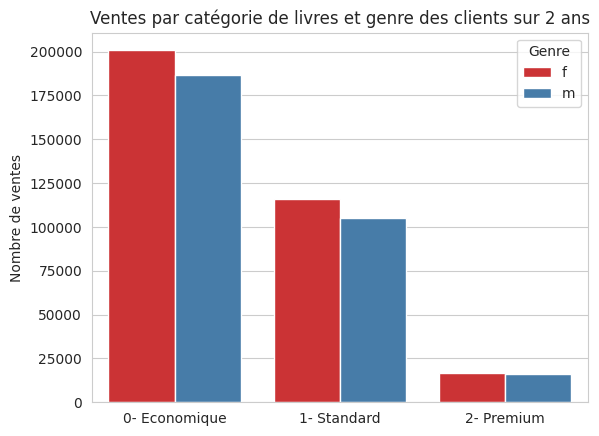

In [127]:
#Visualisation genre vs catégorie de livres
sns.set_style("whitegrid")

sns.barplot(data=df_genre,x='qualif',y='nb_ventes',hue='sex',palette='Set1')

plt.title("Ventes par catégorie de livres et genre des clients sur 2 ans")
plt.legend(title='Genre')
plt.ylabel("Nombre de ventes")
plt.xlabel("")
plt.show()

Conclusion du test statistique :
le genre influence significativement les catégories 0 et 1.
Bien que le test soit positif (il y a une dépendance), l'écart entre le réel et l'attendu reste faible en volume par rapport au nombre total de transactions (plus de 600 000). On en déduit que le genre a une influence réelle mais mineure sur le choix des catégories chez Lapage.

### 9.2 - Corrélation âge vs CA

In [101]:
#Dataframe âge
df_age_ca=df_final_btoc.copy()
df_age_ca=df_age_ca.groupby(['client_id','age']).agg({'price':'sum'})
df_age_ca=df_age_ca.rename(columns={'price':'CA'})
df_age_ca=df_age_ca.sort_values(['age'], ascending=[True]).reset_index()

In [102]:
#Premières lignes
df_age_ca.head()

,client_id,age,CA
0,c_184,22,1450.74
1,c_5436,22,235.80
2,c_5440,22,1355.24
3,c_5457,22,2393.60
4,c_546,22,1537.03


In [103]:
#Dernières lignes
df_age_ca.tail()

,client_id,age,CA
8591,c_4679,96,43.96
8592,c_7232,96,2967.02
8593,c_5302,97,577.01
8594,c_8362,97,842.87
8595,c_577,97,1829.96


In [104]:
#Test statistique de Pearson
correlation, p_value = pearsonr(df_age_ca['age'], df_age_ca['CA'])

print(f"Coefficient de corrélation de Pearson: {correlation}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Pearson: -0.18756654332685188
Valeur p: 6.663511559773103e-69


Observation test statistique :
* Coeff de Pearson < 0 : corrélation linéaire négative faible
* Valeur p < 0,05 (et très proche de 0)

Synthèse test statistique :
* Le montant total des achats à tendance à diminuer légèrement à mesure que l'âge augmente
* Le lien observé est statistiquement significatif (pas de hasard)

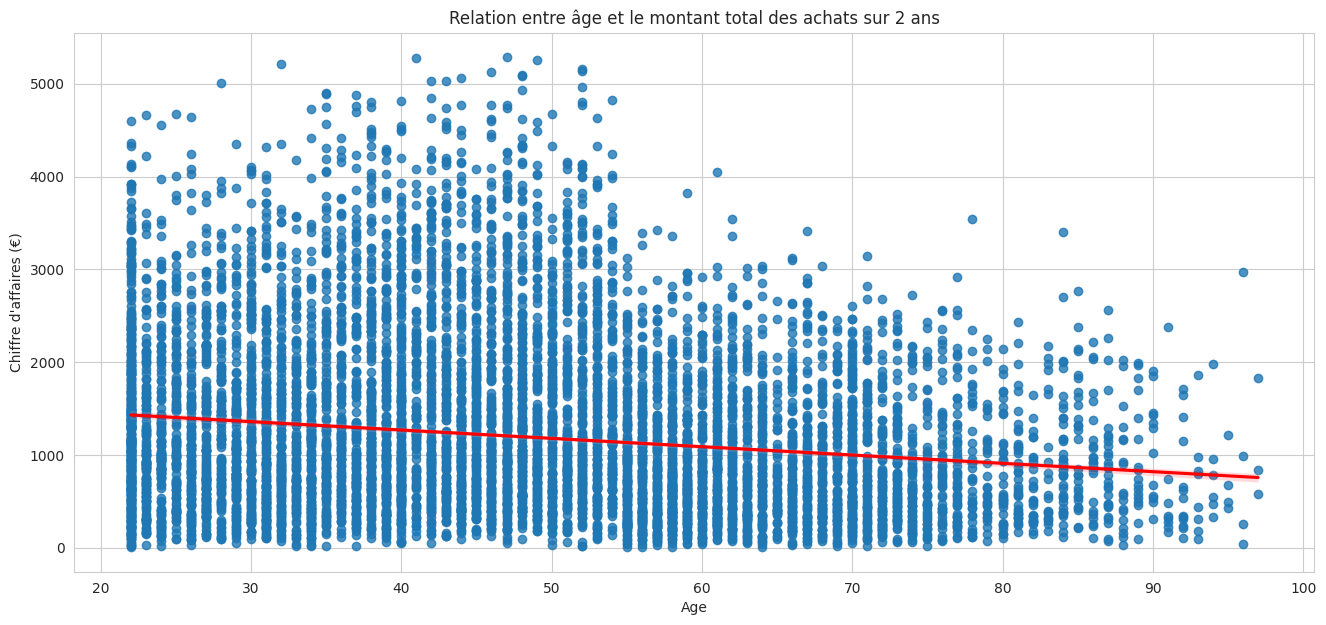

In [125]:
#Visualisation âge vs CA
plt.figure(figsize=(16,7))
sns.set_style("whitegrid")

sns.regplot(data=df_age_ca,x='age',y='CA',robust=True,line_kws=dict(color="r"))

plt.title("Relation entre âge et le montant total des achats sur 2 ans")
plt.ylabel("Chiffre d'affaires (€)")
plt.xlabel("Age")
plt.show()

Observation visualisation :
* Zone de forte dépenses pour les 20-55 ans : dépenses allant jusqu'à 5000€
* Décrochage après 55 ans : plafonds de dépenses chuttent (seuelment quelques uns dépassent les 3000€)
* Plus forte dispertion chez les jeunes

Synthèse visualisation :
* les 20-55 ans sont le coeur du marché
* Les profils de gros acheteurs se rarifient avec l'âge

Conclusion globale :

Le lien est faible mais réel. L'âge n'est pas le facteur prédictif principal du montant total, mais il joue un rôle limitant à partir d'un certain seuil.
Le segment des moins de 55 ans est beaucoup plus hétérogène (mélange de petits et très gros acheteurs), tandis que le segment des seniors est plus homogène avec des dépenses plus modérées.
Mise en évidence de 2 segments distincts : -55ans et +55 ans

### 9.3 - Corrélation âge vs fréquence d'achat

In [106]:
#Dataframe fréquence d'achat
df_frequence=df_final_btoc.copy()
df_frequence=df_frequence.groupby(['client_id','age']).agg({'transaction_id':'count'})
df_frequence=df_frequence.rename(columns={'transaction_id':'frequence'})
df_frequence=df_frequence.sort_values(['frequence'], ascending=[False]).reset_index()

In [107]:
#Premières lignes
df_frequence.head()

,client_id,age,frequence
0,c_2140,49,405
1,c_3263,41,403
2,c_2595,52,398
3,c_2077,42,386
4,c_1637,38,384


In [108]:
#Dernières lignes
df_frequence.tail()

,client_id,age,frequence
8591,c_8351,58,1
8592,c_1624,34,1
8593,c_4478,56,1
8594,c_4223,75,1
8595,c_6292,34,1


In [109]:
#Test statistique de Pearson
correlation, p_value = pearsonr(df_frequence['age'], df_frequence['frequence'])

print(f"Coefficient de corrélation de Pearson: {correlation}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Pearson: 0.03032790187032987
Valeur p: 0.004922261715831478


Observation test statistique :
* Coeff de Pearson > 0 (mais proche de 0)
* Valeur p < 0,05

Synthèse test statistique :
* corrélation linéaire presque nulle
* statistiquement significatif, il y a un lien (pas de hasard)

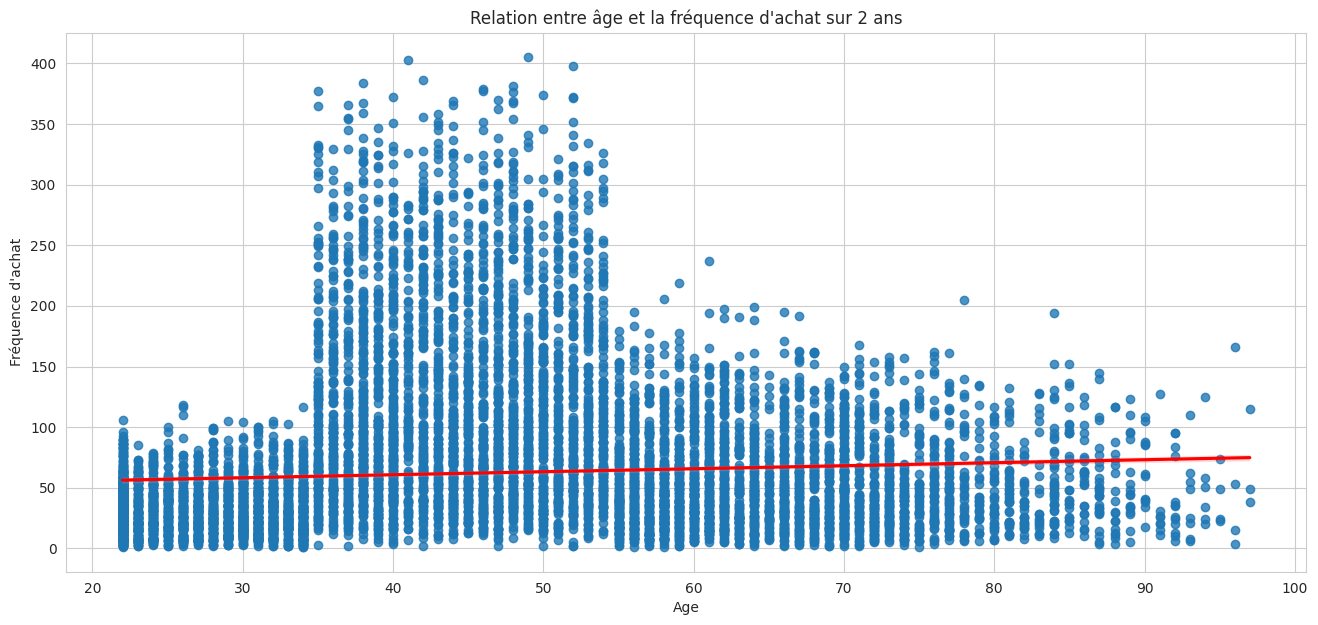

In [124]:
#Visualisation fréquence d'achat vs age
plt.figure(figsize=(16,7))
sns.set_style("whitegrid")

sns.regplot(data=df_frequence,x='age',y='frequence',robust=True,line_kws=dict(color="r"))

plt.title("Relation entre âge et la fréquence d'achat sur 2 ans")
plt.ylabel("Fréquence d'achat")
plt.xlabel("Age")
plt.show()

Observation visualisation :
* 20-35 ans fréquence basse
* 35-55 ans forte fréquence
* +55 ans fréquence en nette baisse

Synthèse visualisation :
* les 35-55 ans achètent le plus souvent
* les +55 ans achètent moins fréquemment
* les 20-35 ans achètent le moins souvent

Conclusion globale :

Mise en évidence de 3 segments distincts : -35 ans (jeunes), 35-55 ans (actifs) et +55 ans (seniors)
Les actifs achètent beaucoup plus souvent que les autres tranchent d'âge.

### 9.4 - Corrélation âge vs panier moyen

In [111]:
#Dataframe panier par client et par date
df_panier=df_final_btoc.copy()
df_panier=df_panier.groupby(['client_id','age','date']).agg({'price':'sum'})
df_panier=df_panier.rename(columns={'price':'panier'})
df_panier=df_panier.sort_values(['panier'], ascending=[False]).reset_index()

In [112]:
#Dataframe panier moyen par âge
df_panier_moyen=df_panier.copy()
df_panier_moyen=df_panier_moyen.groupby(['age']).agg({'panier':'mean'})
df_panier_moyen=df_panier_moyen.rename(columns={'panier':'panier_moyen'})
df_panier_moyen=df_panier_moyen.sort_values(['panier_moyen'], ascending=[False]).reset_index()

In [113]:
#Premières lignes
df_panier_moyen.head()

,age,panier_moyen
0,30,42.434323
1,28,41.455564
2,25,41.415350
3,23,40.231772
4,22,39.786881


In [114]:
#Dernières lignes
df_panier_moyen.tail()

,age,panier_moyen
71,40,13.251198
72,49,13.241548
73,48,13.228994
74,39,13.190540
75,50,13.059298


In [115]:
#Test statistique de Pearson
correlation, p_value = pearsonr(df_panier_moyen['age'], df_panier_moyen['panier_moyen'])

print(f"Coefficient de corrélation de Pearson: {correlation}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Pearson: -0.5444645241394642
Valeur p: 3.692597018589824e-07


Observation test statistique :
* Coeff de Pearson < 0 : corrélation négative modérée
* Valeur p < 0,05 (très proche de 0)

Synthèse test statistique :
* Le montant du panier moyen à tendance à baisser à mesure que l'âge augmente
* Statistiquement hautement significatif, l'âge à un impact certain sur le panier moyen (pas de hasard)

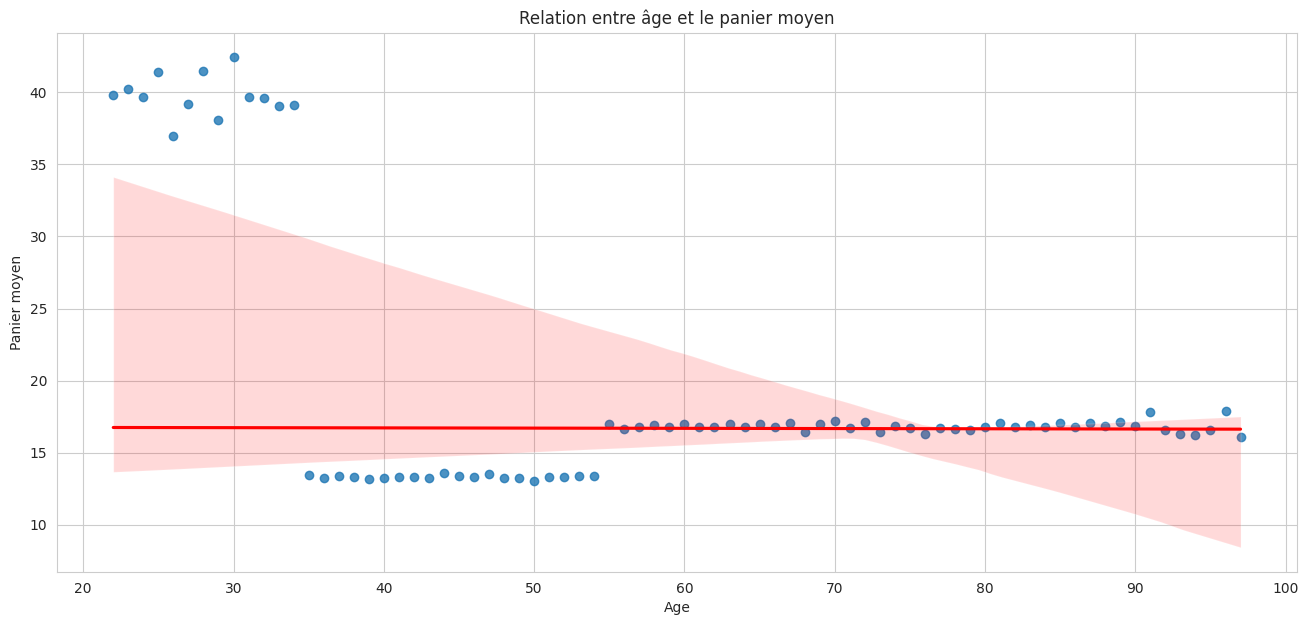

In [128]:
#Visualisation age vs panier moyen
plt.figure(figsize=(16,7))
sns.set_style("whitegrid")

sns.regplot(data=df_panier_moyen,x='age',y='panier_moyen',robust=True,line_kws=dict(color="r"))

plt.title("Relation entre âge et le panier moyen")
plt.ylabel("Panier moyen")
plt.xlabel("Age")
plt.show()

Observation visualisation :
* 20-35 ans panier moyen très élevé (40€)
* 35-55 ans rupture, le panier moyen chute (13€)
* +55 ans le panier moyen remonte légèrement mais reste bas (17€)

Synthèse visualisation :
* les plus jeunes ont un panier moyen plus élevé et une rupture nette se fait à 35 ans.
* L'âge semble avoir un impact significatif

### 9.5 - Age vs catégorie

In [117]:
#Dataframe âge vs catégorie
df_age_categ=df_final_btoc.copy()
df_age_categ=df_age_categ.groupby(['client_id','age','qualif']).agg({'transaction_id':'count'})
df_age_categ=df_age_categ.rename(columns={'transaction_id':'nb_ventes'})
df_age_categ=df_age_categ.sort_values(['qualif','age'], ascending=[True,True]).reset_index()

df_age_categ.info()
print("\n")
df_age_categ.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19940 entries, 0 to 19939
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  19940 non-null  object
 1   age        19940 non-null  int64 
 2   qualif     19940 non-null  object
 3   nb_ventes  19940 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 623.3+ KB




,client_id,age,qualif,nb_ventes
count,19940,19940.000000,19940,19940.000000
unique,8596,NaN,3,NaN
top,c_577,NaN,1- Standard,NaN
freq,3,NaN,8455,NaN
mean,NaN,46.759779,NaN,32.133099
std,NaN,17.073046,NaN,40.751017
min,NaN,22.000000,NaN,1.000000
25%,NaN,32.000000,NaN,8.000000
50%,NaN,45.000000,NaN,19.000000
75%,NaN,59.000000,NaN,39.000000


In [118]:
#Premières lignes
df_age_categ.head()

,client_id,age,qualif,nb_ventes
0,c_1042,22,0- Economique,2
1,c_1046,22,0- Economique,18
2,c_1065,22,0- Economique,1
3,c_1088,22,0- Economique,1
4,c_1094,22,0- Economique,13


In [119]:
#Dernières lignes
df_age_categ.tail()

,client_id,age,qualif,nb_ventes
19935,c_5432,93,2- Premium,1
19936,c_6154,94,2- Premium,2
19937,c_418,95,2- Premium,2
19938,c_7232,96,2- Premium,2
19939,c_577,97,2- Premium,1


In [120]:
#Test statistique ANOVA
economique = df_age_categ[df_age_categ['qualif'] == '0- Economique']['age'].dropna()
standard = df_age_categ[df_age_categ['qualif'] == '1- Standard']['age'].dropna()
premium = df_age_categ[df_age_categ['qualif'] == '2- Premium']['age'].dropna()

f_value, p_value = f_oneway(economique, standard, premium)

print(f"Statistique de test F: {f_value}")
print(f"Valeur p: {p_value}")

Statistique de test F: 574.8473377641184
Valeur p: 1.905353367092059e-243


Observation test statistique :
* Valeur F très élevée
* Valeur p < 0,05 (et très proche de 0)

Synthèse test statistique :
* La variation d'âge entre les catégories et plus importante que celle au sein de chaque catégorie, les groupes sont très distincts
* Statistiquement hautement significatif, l'âge à un impact certain sur la catégorie de livres achetée (pas de hasard)

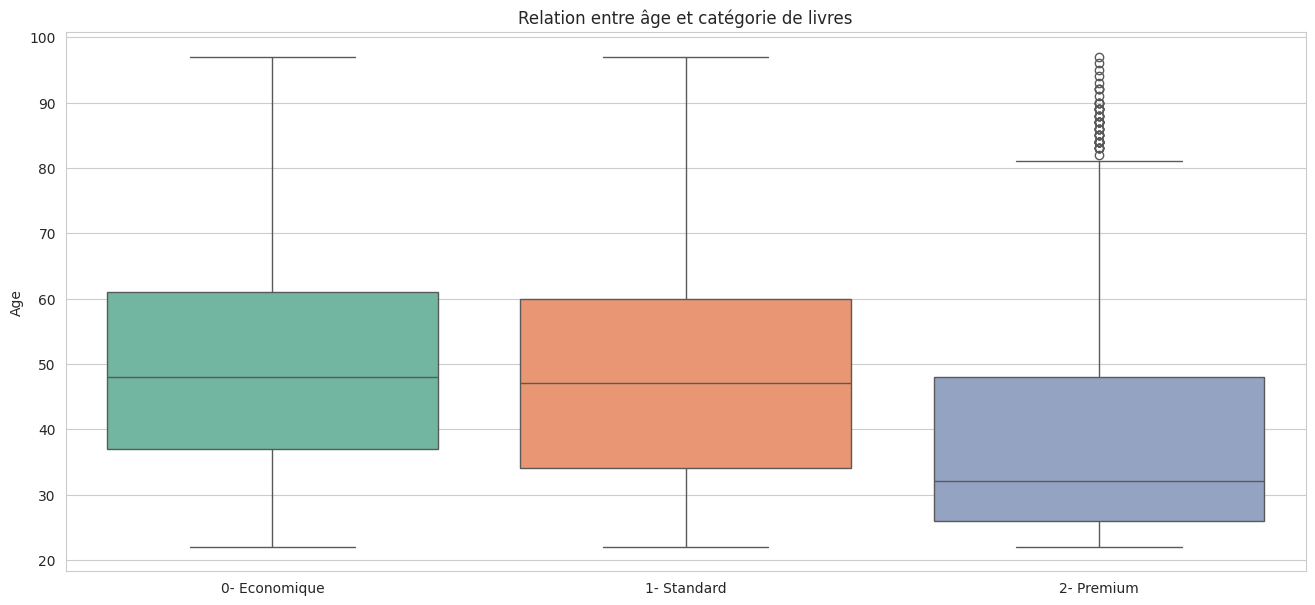

In [121]:
#Visualisation âge vs catégorie
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

sns.boxplot(data=df_age_categ, x='qualif', y='age', hue='qualif', palette=palette_qualif)

plt.title("Relation entre âge et catégorie de livres")
plt.ylabel("Age")
plt.xlabel("")
plt.show()


In [122]:
#Info détaillées
df_age_categ.groupby('qualif')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
qualif,,,,,,,,
0- Economique,7892.0,49.366574,16.455061,22.0,37.0,48.0,61.0,97.0
1- Standard,8455.0,47.888823,16.884218,22.0,34.0,47.0,60.0,97.0
2- Premium,3593.0,38.377122,16.249345,22.0,26.0,32.0,48.0,97.0


Observation visualisation :
* Economique :
  * Médiane : 48 ans
  * Min-max : 22-97 ans
  * Population forte
  * Population condensée entre 37 et 61 ans
* Standard :
  * Médiane : 47 ans
  * Min-max : 22-97 ans
  * Population la plus forte (7% de plus que Economique)
  * Population condensée entre 34 et 60 ans
* Premium :
  * Médiane : 32 ans
  * Min-max : 22-97 ans
  * Population faible (60% de moins que Standard)
  * Population condensée entre 26 et 48 ans
  * Outliers au-delà de 80 ans

Synthèse visualisation :
* Les catégories Economique et Standard concernent principalement une tranche active et globalement plus âgée de la population.
* La catégorie Premium concerne une population plus jeune et ne touche que très peu les plus âgés.

### 9.6 - Conclusion globale des tests statistiques

Ces différents tests statistiques mettent en lumière une prédominance de l'âge sur le genre en tant que facteur d'influence : une segmentation en fonciton des tranches d'âge se dévoile.


3 profils différents :
* 20-35 ans : fréquence d'achat faible mais panier moyen élevé (40€) et population principale de la catégorie Premium.
* 35-55 ans : segment dynamique avec fréquence d'achat très élevée dans les catégories Standard et Economique. Un panier moyen très bas (13€) mais un volume d'achat qui en fait le coeur du marché.
* +55 ans : se déinit par un décrochage net du CA global, une fréquence en baisse et un panier moyen modéré (17€).


Une bonne complémentarité de la gamme :
* Les catégories Enonomique et Standard sont stables en termes de volumes et chiffre d'affaires et concernent une population active et senior.
* La catégorie Premium est un levier de valeur pour la jeunesse qui compense la faible fréquence d'achat par un panier plus élevé. Cette population déjà conquise pourra, à terme, glisser petit à petit vers les deux autres gammes.